## Task 1

In [4]:
import numpy as np
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

x = data.data

y = data.target.reshape(-1, 1)

print("Shape of X: ", x.shape)
print("Shape of Y: ", y.shape)

Shape of X:  (20640, 8)
Shape of Y:  (20640, 1)


In [5]:
np.random.seed(9432)
n = x.shape[0]
indices = np.random.permutation(n)

train_end = int(0.60*n)
val_end = int(0.80*n)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

x_train = x[train_indices]
y_train = y[train_indices]

x_val = x[val_indices]
y_val = y[val_indices]

x_test = x[test_indices]
y_test = y[test_indices]

print("Training set: ")
print("x_train: ", x_train.shape)
print("y_train: ", y_train.shape)

print("\nValidation set: ")
print("x_val: ", x_val.shape)
print("y_val: ", y_val.shape)

print("\nTest set: ")
print("x_test: ", x_test.shape)
print("y_test: ", y_test.shape)

Training set: 
x_train:  (12384, 8)
y_train:  (12384, 1)

Validation set: 
x_val:  (4128, 8)
y_val:  (4128, 1)

Test set: 
x_test:  (4128, 8)
y_test:  (4128, 1)


In [6]:
x_mean = np.mean(x_train, axis=0)
x_std = np.std(x_train, axis=0)

x_train_norm = (x_train - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_test_norm = (x_test - x_mean) / x_std

print("Training mean: ")
print(x_mean)
print("Training Standard Deviation: ")
print(x_std)

Training mean: 
[ 3.85596161e+00  2.86526970e+01  5.42962223e+00  1.09884519e+00
  1.41660021e+03  3.03186757e+00  3.56333664e+01 -1.19564612e+02]
Training Standard Deviation: 
[1.90801811e+00 1.25882840e+01 2.43426411e+00 4.93702962e-01
 1.07508341e+03 7.10895963e+00 2.14535603e+00 2.00656429e+00]


In [7]:
print("Mean of normalized training set: ")
print(np.mean(x_train_norm, axis=0))

print("Standard Deviation of normalized training set: ")
print(np.std(x_train_norm, axis=0))

Mean of normalized training set: 
[ 6.67028520e-15 -4.05687721e-17 -1.97551946e-15 -9.56487359e-15
 -1.04742335e-16  1.83242942e-15  2.76463194e-14 -1.64395485e-13]
Standard Deviation of normalized training set: 
[1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
x_train_aug = np.hstack((np.ones((x_train_norm.shape[0], 1)), x_train_norm))

x_val_aug = np.hstack((np.ones((x_val_norm.shape[0], 1)), x_val_norm))

x_test_aug = np.hstack((np.ones((x_test_norm.shape[0], 1)), x_test_norm))

print("x_train_aug shape: ", x_train_aug.shape)
print("x_val_aug shape: ", x_val_aug.shape)
print("x_test_aug shape: ", x_test_aug.shape)

x_train_aug shape:  (12384, 9)
x_val_aug shape:  (4128, 9)
x_test_aug shape:  (4128, 9)


In [9]:
y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

y_train_std = (y_train - y_mean) / y_std
y_val_std = (y_val - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std

print("Training target mean: ")
print(y_mean)
print("\nTraining target standard deviation: ")
print(y_std)

Training target mean: 
[2.05829457]

Training target standard deviation: 
[1.15741395]


In [10]:
print("Mean of standardized training target: ")
print(np.mean(y_train_std, axis=0))

print("Standard Deviation of standardizes training target: ")
print(np.std(y_train_std, axis=0))

Mean of standardized training target: 
[9.78258531e-17]
Standard Deviation of standardizes training target: 
[1.]


## Task 2

In [11]:
def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    mse = np.mean(error ** 2)
    return mse

actual = np.array([[2], [4], [6]])
predicted = np.array([[1], [5], [5]])

loss = mse_loss(actual, predicted)

print("MSE:", loss)

MSE: 1.0


In [12]:
def mse_gradient(x_batch, y_batch, weights):
    m = x_batch.shape[0]

    predictions = x_batch @ weights

    error = predictions - y_batch

    gradient = (2 / m) * (x_batch.T @ error)

    return gradient

In [13]:
def mini_batch_gradient_descent(
    x_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    batch_size,
    max_epochs=1000,
    patience=100
):
   weights = np.zeros((x_train.shape[1], 1))

   train_losses = []
   val_losses = []

   best_val_loss = float('inf')
   best_weights = weights.copy()
   best_epoch = 0

   epochs_without_improvement = 0

   n = x_train.shape[0]

   for epoch in range(1, max_epochs + 1):
      indices = np.random.permutation(n)
      x_shuffled = x_train[indices]
      y_shuffled = y_train[indices]

      total_loss = 0
      total_samples = 0

      for start in range(0, n, batch_size):
        end = min(start+ + batch_size, n)

        x_batch = x_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        batch_samples = x_batch.shape[0]

        predictions = x_batch @ weights

        batch_loss = mse_loss(y_batch, predictions)

        total_loss += batch_samples*batch_loss
        total_samples += batch_samples

        gradient = mse_gradient(
                x_batch,
                y_batch,
                weights
            )
        weights = weights - learning_rate * gradient

      epoch_train_loss = total_loss / total_samples

      val_predictions = X_val @ weights

      epoch_val_loss = mse_loss(
            y_val,
            val_predictions
        )
      train_losses.append(epoch_train_loss)
      val_losses.append(epoch_val_loss)

      if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_weights = weights.copy()
        best_epoch = epoch
        epochs_without_improvement = 0
      else:
        epochs_without_improvement += 1

      if epochs_without_improvement >= patience:
        print("Early stopping at epoch: ", epoch)
        break

   return (
        best_weights,
        best_epoch,
        np.array(train_losses),
        np.array(val_losses)
    )


learning_rate = 0.001
batch_size = 128


In [14]:
best_weights, best_epoch, train_losses, val_losses = mini_batch_gradient_descent(
    x_train_aug,
    y_train_std,
    x_val_aug,
    y_val_std,
    learning_rate=learning_rate,
    batch_size=batch_size,
    max_epochs=1000,
    patience=100
)

print("Best epoch:", best_epoch)
print("Lowest validation MSE:", np.min(val_losses))
print("Number of epochs completed:", len(train_losses))

Early stopping at epoch:  393
Best epoch: 293
Lowest validation MSE: 0.3916782667777206
Number of epochs completed: 393


## Task 3

In [15]:
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]

batch_size = 128
results_lr = {}

for i, lr in enumerate(learning_rates):
  print("Running learning rates: ", lr)

  np.random.seed(9432+i)

  best_weights, best_epoch, train_losses, val_losses = mini_batch_gradient_descent(
        x_train_aug,
        y_train_std,
        x_val_aug,
        y_val_std,
        learning_rate=lr,
        batch_size=batch_size,
        max_epochs=1000,
        patience=100
    )
  results_lr[lr] = {
        "weights": best_weights,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_mse": np.min(val_losses)
    }
  print("Best epoch:", best_epoch)
  print("Best validation MSE:", np.min(val_losses))
  print()

Running learning rates:  1e-05
Best epoch: 1000
Best validation MSE: 0.4714942689305008

Running learning rates:  0.0001
Best epoch: 1000
Best validation MSE: 0.3968490585222805

Running learning rates:  0.001
Early stopping at epoch:  463
Best epoch: 363
Best validation MSE: 0.3917027412978372

Running learning rates:  0.01
Early stopping at epoch:  267
Best epoch: 167
Best validation MSE: 0.3905351821734116

Running learning rates:  0.1


/tmp/ipykernel_1544/1363381139.py:44: RuntimeWarning: overflow encountered in scalar add
  total_loss += batch_samples*batch_loss
/tmp/ipykernel_1544/924499302.py:3: RuntimeWarning: overflow encountered in square
  mse = np.mean(error ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1544/771730396.py:8: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / m) * (x_batch.T @ error)
/tmp/ipykernel_1544/1363381139.py:40: RuntimeWarning: invalid value encountered in matmul
  predictions = x_batch @ weights
/tmp/ipykernel_1544/771730396.py:4: RuntimeWarning: invalid value encountered in matmul
  predictions = x_batch @ weights
/tmp/ipykernel_1544/771730396.py:8: RuntimeWarning: invalid value encountered in matmul
  gradient = (2 / m) * (x_batch.T @ error)


Early stopping at epoch:  101
Best epoch: 1
Best validation MSE: 788.9604668911905

Running learning rates:  1
Early stopping at epoch:  101
Best epoch: 1
Best validation MSE: nan

Running learning rates:  10
Early stopping at epoch:  100
Best epoch: 0
Best validation MSE: nan



In [16]:
import pandas as pd

lr_table = []

for lr in learning_rates:

    lr_table.append({
        "Learning Rate": lr,
        "Best Epoch": results_lr[lr]["best_epoch"],
        "Lowest Validation MSE": results_lr[lr]["best_val_mse"]
    })

lr_results_df = pd.DataFrame(lr_table)

print(lr_results_df)

   Learning Rate  Best Epoch  Lowest Validation MSE
0        0.00001        1000               0.471494
1        0.00010        1000               0.396849
2        0.00100         363               0.391703
3        0.01000         167               0.390535
4        0.10000           1             788.960467
5        1.00000           1                    NaN
6       10.00000           0                    NaN


In [17]:
best_lr = min(
    learning_rates,
    key=lambda lr: results_lr[lr]["best_val_mse"]
)

best_lr_mse = results_lr[best_lr]["best_val_mse"]
best_lr_epoch = results_lr[best_lr]["best_epoch"]

print("Best learning rate:", best_lr)
print("Lowest validation MSE:", best_lr_mse)
print("Best epoch:", best_lr_epoch)

Best learning rate: 0.01
Lowest validation MSE: 0.3905351821734116
Best epoch: 167


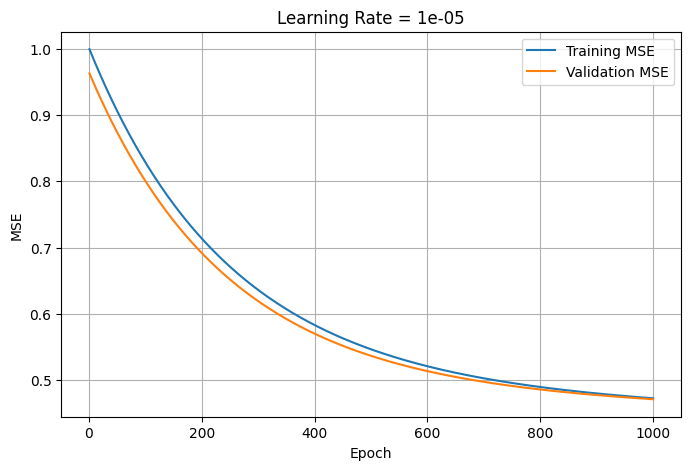

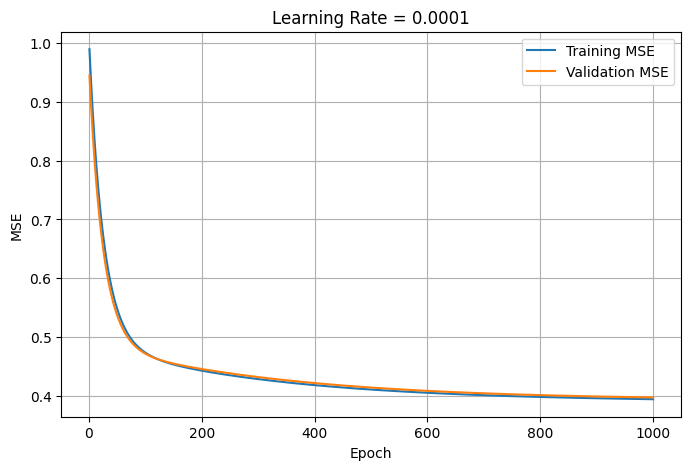

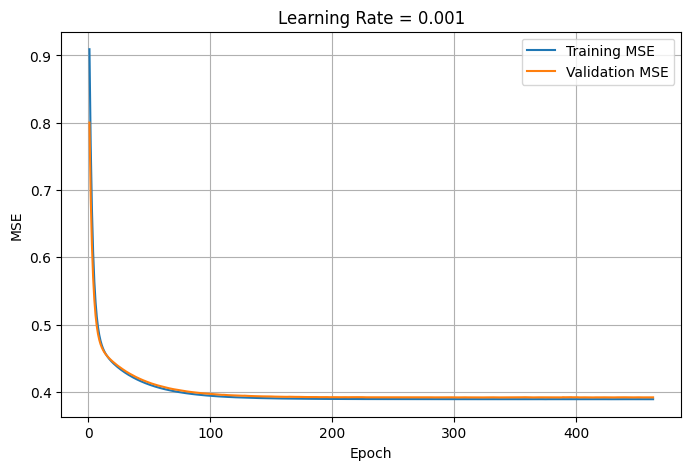

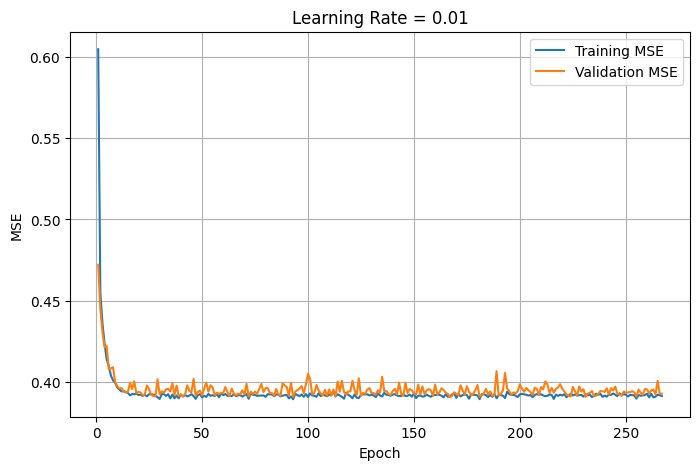

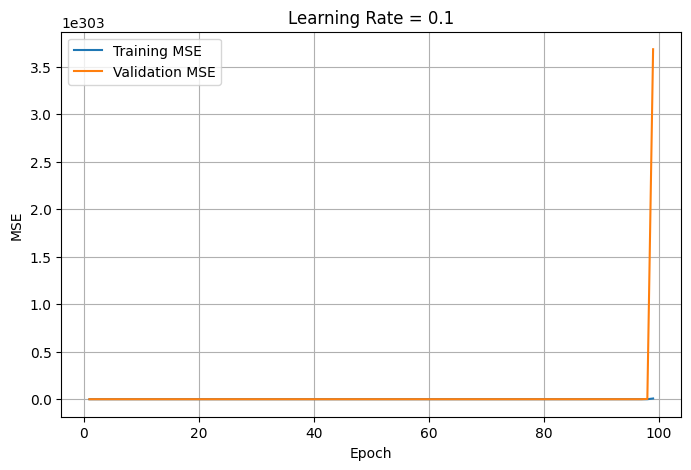

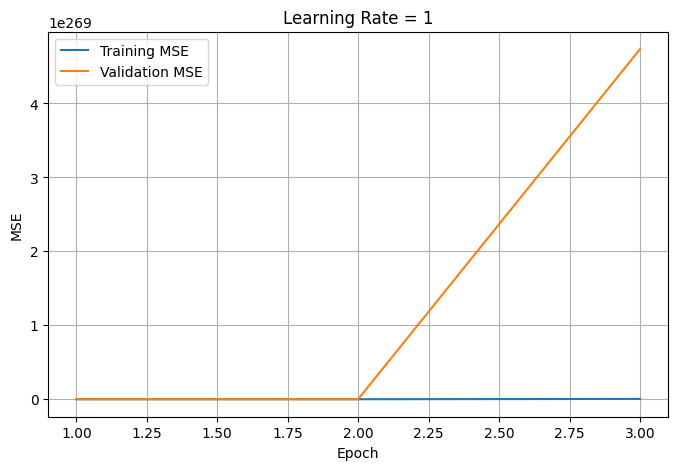

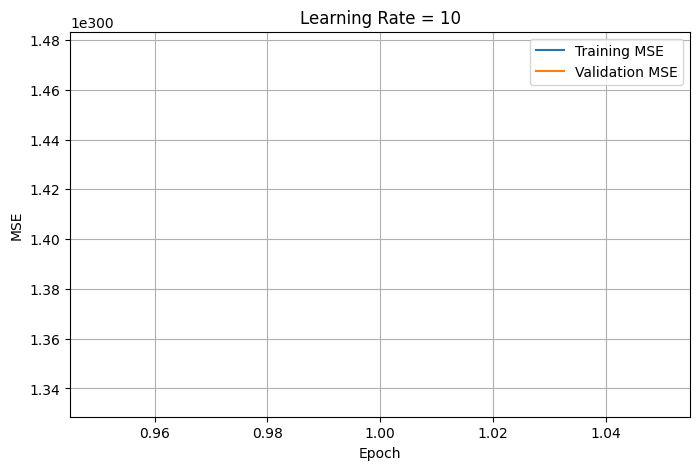

In [19]:
import matplotlib.pyplot as plt

for lr in learning_rates:

    train_losses = results_lr[lr]["train_losses"]
    val_losses = results_lr[lr]["val_losses"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_losses,
        label="Training MSE"
    )

    plt.plot(
        epochs,
        val_losses,
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [20]:
best_lr_weights = results_lr[best_lr]["weights"]

print("Best learning rate:", best_lr)
print("Shape of best weights:", best_lr_weights.shape)

Best learning rate: 0.01
Shape of best weights: (9, 1)


## Task 4

In [21]:
learning_rate = 0.01
batch_sizes = [16, 32, 64, 128, 256, 512, 1024]

results_batch = {}

for i, batch_size in enumerate(batch_sizes):

    print("=" * 50)
    print("Batch Size:", batch_size)

    np.random.seed(10000 + i)

    best_weights, best_epoch, train_losses, val_losses = (
        mini_batch_gradient_descent(
            x_train_aug,
            y_train_std,
            x_val_aug,
            y_val_std,
            learning_rate=best_lr,
            batch_size=batch_size,
            max_epochs=1000,
            patience=100
        )
    )

    results_batch[batch_size] = {
        "weights": best_weights,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_mse": np.min(val_losses)
    }

    print("Best epoch:", best_epoch)
    print("Lowest validation MSE:", np.min(val_losses))


Batch Size: 16
Early stopping at epoch:  101
Best epoch: 1
Lowest validation MSE: 0.7364632292684995
Batch Size: 32
Early stopping at epoch:  101
Best epoch: 1
Lowest validation MSE: 1.0458585538094929
Batch Size: 64
Early stopping at epoch:  194
Best epoch: 94
Lowest validation MSE: 0.389957088737943
Batch Size: 128
Early stopping at epoch:  314
Best epoch: 214
Lowest validation MSE: 0.39046739803497815
Batch Size: 256
Early stopping at epoch:  232
Best epoch: 132
Lowest validation MSE: 0.3910440358082812
Batch Size: 512
Early stopping at epoch:  259
Best epoch: 159
Lowest validation MSE: 0.3911878122687094
Batch Size: 1024
Early stopping at epoch:  312
Best epoch: 212
Lowest validation MSE: 0.3908884929415711


In [22]:
batch_table = []

for batch_size in batch_sizes:

    batch_table.append({
        "Batch Size": batch_size,
        "Best Epoch": results_batch[batch_size]["best_epoch"],
        "Lowest Validation MSE": results_batch[batch_size]["best_val_mse"]
    })

batch_results_df = pd.DataFrame(batch_table)

display(batch_results_df)

,Batch Size,Best Epoch,Lowest Validation MSE
0,16,1,0.736463
1,32,1,1.045859
2,64,94,0.389957
3,128,214,0.390467
4,256,132,0.391044
5,512,159,0.391188
6,1024,212,0.390888


In [23]:
best_batch_size = min(
    batch_sizes,
    key=lambda batch_size:
        results_batch[batch_size]["best_val_mse"]
)

best_batch_mse = results_batch[best_batch_size]["best_val_mse"]

best_batch_epoch = results_batch[best_batch_size]["best_epoch"]

print("Best batch size:", best_batch_size)
print("Lowest validation MSE:", best_batch_mse)
print("Best epoch:", best_batch_epoch)

Best batch size: 64
Lowest validation MSE: 0.389957088737943
Best epoch: 94


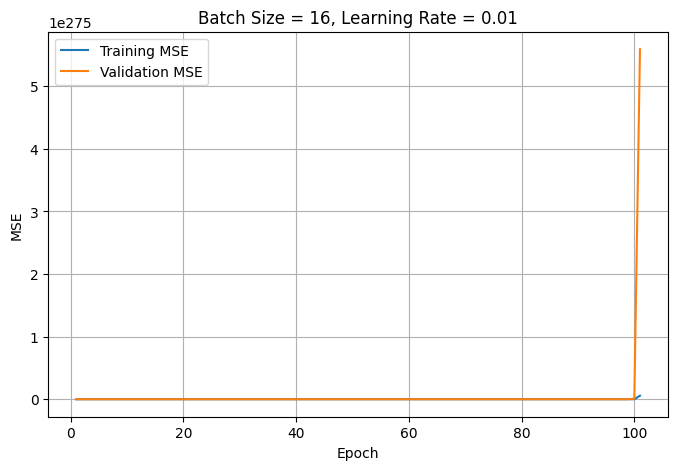

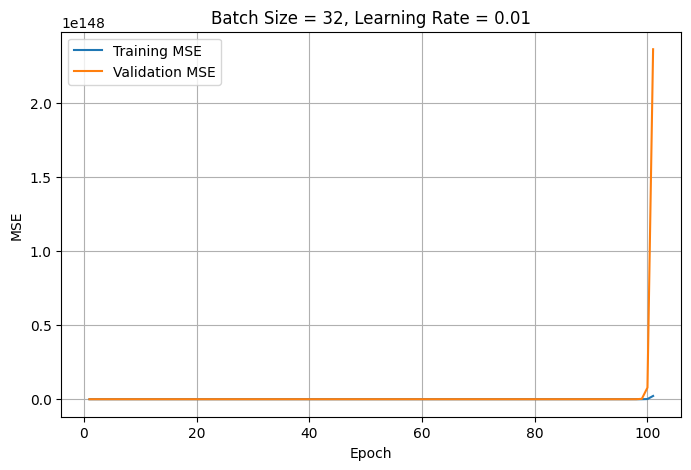

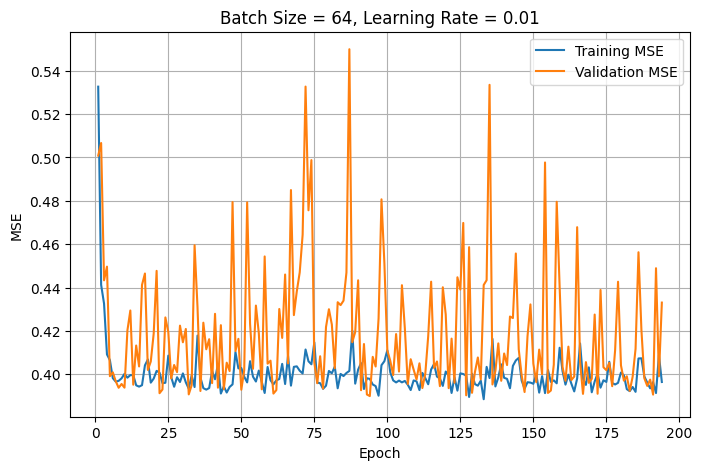

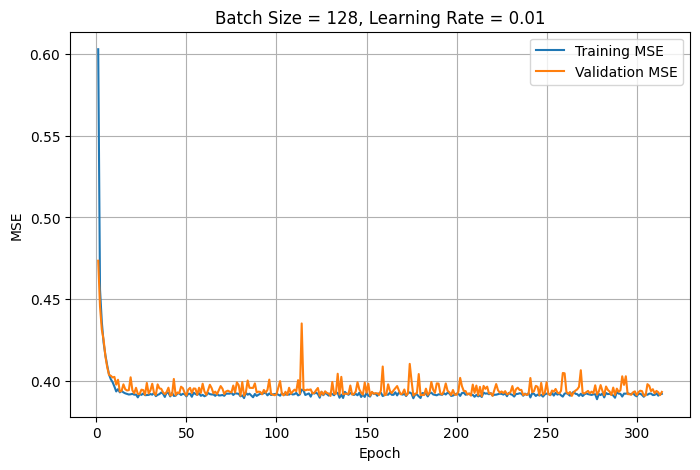

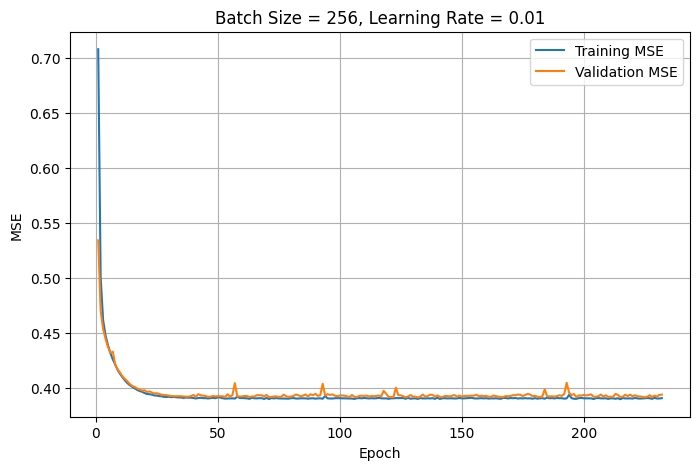

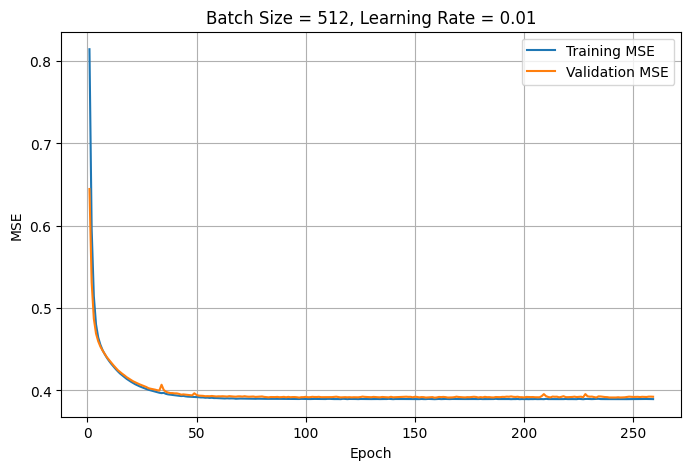

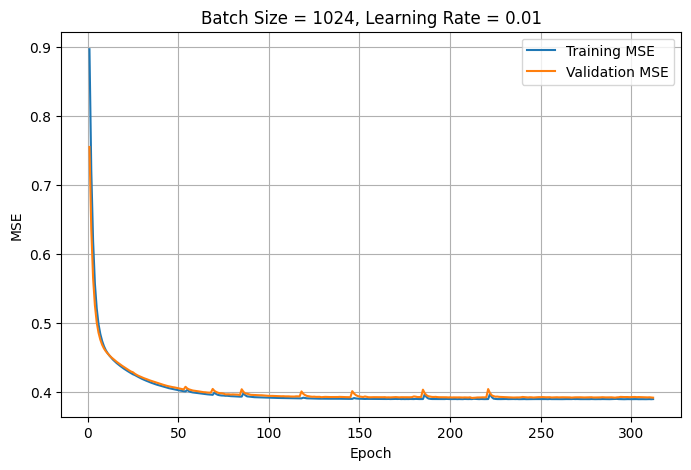

In [24]:
for batch_size in batch_sizes:

    train_losses = results_batch[batch_size]["train_losses"]
    val_losses = results_batch[batch_size]["val_losses"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_losses,
        label="Training MSE"
    )

    plt.plot(
        epochs,
        val_losses,
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(
        f"Batch Size = {batch_size}, Learning Rate = {best_lr}"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

## Task 5

In [25]:
np.random.seed(20000)

final_weights, final_best_epoch, final_train_losses, final_val_losses = (
    mini_batch_gradient_descent(
        x_train_aug,
        y_train_std,
        x_val_aug,
        y_val_std,
        learning_rate=best_lr,
        batch_size=best_batch_size,
        max_epochs=1000,
        patience=100
    )
)

print("Final model training completed.")
print("Best epoch:", final_best_epoch)
print("Best validation MSE:", np.min(final_val_losses))

Early stopping at epoch:  277
Final model training completed.
Best epoch: 177
Best validation MSE: 0.3903067214750008


In [26]:
y_train_pred_std = x_train_aug @ final_weights
y_val_pred_std = x_val_aug @ final_weights
y_test_pred_std = x_test_aug @ final_weights

y_train_pred = y_train_pred_std * y_std + y_mean
y_val_pred = y_val_pred_std * y_std + y_mean
y_test_pred = y_test_pred_std * y_std + y_mean

train_mse = mse_loss(y_train, y_train_pred)
val_mse = mse_loss(y_val, y_val_pred)
test_mse = mse_loss(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

Training MSE: 0.5270782955664817
Validation MSE: 0.5228576352695958
Test MSE: 0.5308103280329494


In [27]:
def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )
def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )
def mape(y_true, y_pred):
    return np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100
def r2_score_manual(y_true, y_pred):

    y_mean_value = np.mean(y_true)

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - y_mean_value) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [28]:
train_rmse = rmse(
    y_train,
    y_train_pred
)

train_mape = mape(
    y_train,
    y_train_pred
)

train_mae = mae(
    y_train,
    y_train_pred
)

train_r2 = r2_score_manual(
    y_train,
    y_train_pred
)

In [29]:
val_rmse = rmse(
    y_val,
    y_val_pred
)

val_mape = mape(
    y_val,
    y_val_pred
)

val_mae = mae(
    y_val,
    y_val_pred
)

val_r2 = r2_score_manual(
    y_val,
    y_val_pred
)

In [30]:
test_rmse = rmse(
    y_test,
    y_test_pred
)

test_mape = mape(
    y_test,
    y_test_pred
)

test_mae = mae(
    y_test,
    y_test_pred
)

test_r2 = r2_score_manual(
    y_test,
    y_test_pred
)

In [31]:
final_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],

    "RMSE": [
        train_rmse,
        val_rmse,
        test_rmse
    ],

    "MAPE (%)": [
        train_mape,
        val_mape,
        test_mape
    ],

    "MAE": [
        train_mae,
        val_mae,
        test_mae
    ],

    "R-squared": [
        train_r2,
        val_r2,
        test_r2
    ]
})

In [32]:
final_results[
    ["RMSE", "MAPE (%)", "MAE", "R-squared"]
] = final_results[
    ["RMSE", "MAPE (%)", "MAE", "R-squared"]
].round(5)

display(final_results)

,Dataset,RMSE,MAPE (%),MAE,R-squared
0,Training,0.72600,31.41946,0.52696,0.60654
1,Validation,0.72309,31.25920,0.53176,0.59531
2,Test,0.72857,31.15611,0.53104,0.60556


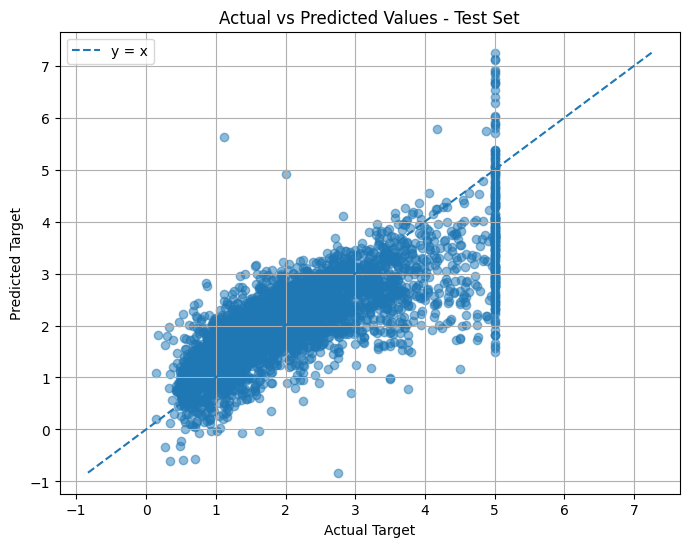

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

minimum = min(
    np.min(y_test),
    np.min(y_test_pred)
)

maximum = max(
    np.max(y_test),
    np.max(y_test_pred)
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="y = x"
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")

plt.title(
    "Actual vs Predicted Values - Test Set"
)

plt.legend()
plt.grid(True)

plt.show()